
number of images : 13690<br>

empty labels: 391 (Removed)<br>

| Class ID | Class Name | Training Count | Validation Count |
| -------- | ---------- | -------------- | ---------------- |
| 0        | aeroplane  | 808            | 194              |
| 1        | bicycle    | 695            | 142              |
| 2        | bird       | 1056           | 215              |
| 3        | boat       | 854            | 205              |
| 4        | bottle     | 1226           | 335              |
| 5        | bus        | 537            | 148              |
| 6        | car        | 1988           | 503              |
| 7        | cat        | 1034           | 243              |
| 8        | chair      | 2467           | 588              |
| 9        | cow        | 638            | 133              |
| 10       | table      | 618            | 182              |
| 11       | dog        | 1234           | 364              |
| 12       | horse      | 611            | 192              |
| 13       | motorcycle | 640            | 160              |
| 14       | person     | 13168          | 3289             |
| 15       | plant      | 951            | 251              |
| 16       | goat       | 858            | 226              |
| 17       | couch      | 677            | 164              |
| 18       | train      | 561            | 143              |
| 19       | monitor    | 735            | 158              |



In [2]:
import pandas as pd
import os
import numpy as np
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [37]:
#training
voc_dir = r"roboflow\\train\\labels"

emptytxt = []
class_counter = {i: 0 for i in range(20)}

for i,file in enumerate( os.listdir(voc_dir)):
  with open(os.path.join(voc_dir,file),"r") as f:
    lines = f.readlines()

    #check for empty labels
    if len(lines) == 0:
      emptytxt.append(file)

    #get class counters
    for line in lines:
      class_counter[int(line.split()[0])] += 1


print(f"empty train labels: {len(emptytxt)}")
print(f"tranining class count:{class_counter}")

#validation
voc_dir = r"roboflow\valid\labels"

emptytxt = []
class_counter = {i: 0 for i in range(20)}

for i,file in enumerate( os.listdir(voc_dir)):
  with open(os.path.join(voc_dir,file),"r") as f:
    lines = f.readlines()

    #check for empty labels
    if len(lines) == 0:
      emptytxt.append(file)

    #get class counters
    for line in lines:
      class_counter[int(line.split()[0])] += 1


print(f"empty valid labels: {len(emptytxt)}")
print(f"validation class count:{class_counter}")



empty train labels: 0
tranining class count:{0: 808, 1: 695, 2: 1056, 3: 854, 4: 1226, 5: 537, 6: 1988, 7: 1034, 8: 2467, 9: 638, 10: 618, 11: 1234, 12: 611, 13: 640, 14: 13168, 15: 951, 16: 858, 17: 677, 18: 561, 19: 735}
empty valid labels: 0
validation class count:{0: 194, 1: 142, 2: 215, 3: 205, 4: 335, 5: 148, 6: 503, 7: 243, 8: 588, 9: 133, 10: 182, 11: 364, 12: 192, 13: 160, 14: 3289, 15: 251, 16: 226, 17: 164, 18: 143, 19: 158}


In [38]:
#training 
label_dir = r"roboflow\train\labels"
image_dir = r"roboflow\train\images"


for file in emptytxt:
    label_path = os.path.join(label_dir, file)

    # Delete label file if it exists
    if os.path.exists(label_path):
        os.remove(label_path)
        print(f"Deleted label: {label_path}")

    # Build corresponding image path
    img_name = file[:-4] + ".jpg"
    img_path = os.path.join(image_dir, img_name)

    # Delete image if it exists
    if os.path.exists(img_path):
        os.remove(img_path)
        print(f"Deleted image: {img_path}")

#validation
label_dir = r"roboflow\valid\labels"
image_dir = r"roboflow\valid\images"

for file in emptytxt:
    label_path = os.path.join(label_dir, file)

    # Delete label file if it exists
    if os.path.exists(label_path):
        os.remove(label_path)
        print(f"Deleted label: {label_path}")

    # Build corresponding image path
    img_name = file[:-4] + ".jpg"
    img_path = os.path.join(image_dir, img_name)

    # Delete image if it exists
    if os.path.exists(img_path):
        os.remove(img_path)
        print(f"Deleted image: {img_path}")




In [39]:
seen_ids = set() 

image_files = [
    os.path.join(root, f)
    for root, _, files in os.walk(image_dir)
    for f in files
]

label_files = [
    os.path.join(root, f)
    for root, _, files in os.walk(label_dir)
    for f in files
]

for img_file, lbl_file in zip(image_files, label_files):
    # Read all labels for this image
    with open(lbl_file, "r") as f:
        lines = f.readlines()

    ids_in_image = set()
    boxes = []

    for line in lines:
        cls, x_center, y_center, width, height = map(float, line.strip().split())
        ids_in_image.add(int(cls))
        boxes.append((int(cls), x_center, y_center, width, height))

    # Check if there’s any *new* ID in this image
    new_ids = ids_in_image - seen_ids

    if new_ids:  # means we found at least one unseen ID
        print(f"New IDs {new_ids} found in {img_file}")

        # Show image with all labels
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        for cls, x_center, y_center, width, height in boxes:
            x1 = int((x_center - width / 2) * w)
            y1 = int((y_center - height / 2) * h)
            x2 = int((x_center + width / 2) * w)
            y2 = int((y_center + height / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, f"Class {cls}", (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        plt.imshow(img)
        plt.axis("off")
        plt.show()

        # Add these new IDs to our seen set
        seen_ids.update(new_ids)


New IDs {19} found in roboflow\valid\images\2007_000039_jpg.rf.eb878cf899cc46bcc3a2d91c6dfede0d.jpg


<Figure size 640x480 with 1 Axes>

New IDs {18} found in roboflow\valid\images\2007_000042_jpg.rf.21843925939a653bd7530db380564108.jpg


<Figure size 640x480 with 1 Axes>

New IDs {8, 11} found in roboflow\valid\images\2007_000063_jpg.rf.16bcc21d9560419290a752f8d6439caf.jpg


...

<Figure size 640x480 with 1 Axes>

New IDs {5} found in roboflow\valid\images\2007_002216_jpg.rf.3fd27e781261d9b8a5127e5ea982fdf1.jpg


<Figure size 640x480 with 1 Axes>

New IDs {16} found in roboflow\valid\images\2007_007621_jpg.rf.082afac36a112bd9f1d84b47be6cea01.jpg


<Figure size 640x480 with 1 Axes>

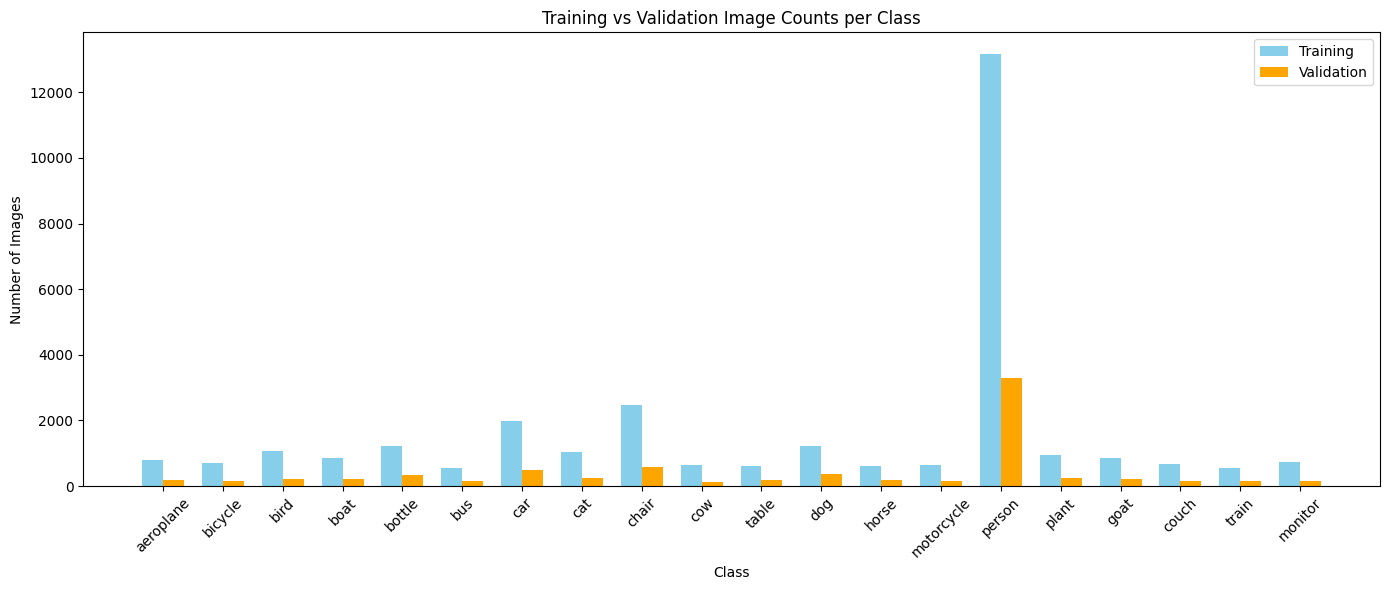

In [42]:
train_class_counts = {
    0: {"name": "aeroplane", "count": 808},
    1: {"name": "bicycle", "count": 695},
    2: {"name": "bird", "count": 1056},
    3: {"name": "boat", "count": 854},
    4: {"name": "bottle", "count": 1226},
    5: {"name": "bus", "count": 537},
    6: {"name": "car", "count": 1988},
    7: {"name": "cat", "count": 1034},
    8: {"name": "chair", "count": 2467},
    9: {"name": "cow", "count": 638},
    10: {"name": "table", "count": 618},
    11: {"name": "dog", "count": 1234},
    12: {"name": "horse", "count": 611},
    13: {"name": "motorcycle", "count": 640},
    14: {"name": "person", "count": 13168},
    15: {"name": "plant", "count": 951},
    16: {"name": "goat", "count": 858},
    17: {"name": "couch", "count": 677},
    18: {"name": "train", "count": 561},
    19: {"name": "monitor", "count": 735},
}
valid_class_counts ={
    0: {"name": "aeroplane", "count": 194},
    1: {"name": "bicycle", "count": 142},
    2: {"name": "bird", "count": 215},
    3: {"name": "boat", "count": 205},
    4: {"name": "bottle", "count": 335},
    5: {"name": "bus", "count": 148},
    6: {"name": "car", "count": 503},
    7: {"name": "cat", "count": 243},
    8: {"name": "chair", "count": 588},
    9: {"name": "cow", "count": 133},
    10: {"name": "table", "count": 182},
    11: {"name": "dog", "count": 364},
    12: {"name": "horse", "count": 192},
    13: {"name": "motorcycle", "count": 160},
    14: {"name": "person", "count": 3289},
    15: {"name": "plant", "count": 251},
    16: {"name": "goat", "count": 226},
    17: {"name": "couch", "count": 164},
    18: {"name": "train", "count": 143},
    19: {"name": "monitor", "count": 158},
}

# Extract class names
class_names = [train_class_counts[i]["name"] for i in range(20)]

# Extract counts
train_counts = [train_class_counts[i]["count"] for i in range(20)]
valid_counts = [valid_class_counts[i]["count"] for i in range(20)]

# Plotting
x = range(len(class_names))
width = 0.35  # width of bars

plt.figure(figsize=(14,6))
plt.bar(x, train_counts, width=width, label='Training', color='skyblue')
plt.bar([i + width for i in x], valid_counts, width=width, label='Validation', color='orange')

plt.Figure(figsize=(9,9))
# Labels and ticks
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Training vs Validation Image Counts per Class')
plt.xticks([i + width/2 for i in x], class_names, rotation=45)
plt.legend()
plt.tight_layout()
%matplotlib inline
plt.show()

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 model (you can use yolov8n, yolov8s, yolov8m, etc.)
model = YOLO("yolov8n.pt")

results = model.train(
    data="roboflow/data.yaml",  # Path to your dataset YAML file
    epochs=100,                 # Number of epochs
    imgsz=640,                  # Image size
    batch=16,                   # Batch size
    workers=4,                  # Number of dataloader workers
    device=0                    # 0 for GPU, 'cpu' if no CUDA
    
)


New https://pypi.org/project/ultralytics/8.3.221 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.220  Python-3.13.5 torch-2.9.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=roboflow/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None,

In [ ]:
model.val(data="roboflow/data.yaml", batch=8, device=0)

Ultralytics 8.3.220  Python-3.13.5 torch-2.9.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
Model summary (fused): 72 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 364.5135.6 MB/s, size: 34.0 KB)
val: Scanning C:\Users\minef\Desktop\college\Final Project\roboflow\valid\labels... 3302 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3302/3302 3.7Kit/s 0.9s0.1s
val: New cache created: C:\Users\minef\Desktop\college\Final Project\roboflow\valid\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 413/413 24.2it/s 17.0s<0.0s
                   all       3302       7835      0.719      0.612      0.673      0.506
             aeroplane        134        194      0.858      0.717      0.785      0.618
               bicycle        107        142      0.634      0.556      0.635      0.476
                  bird        146        215       0.72       0.61      0.64

In [43]:
model.benchmark(data="roboflow/data.yaml", batch=16, device=0, imgsz=640)

Setup complete  (12 CPUs, 15.6 GB RAM, 708.8/952.6 GB disk)

Benchmarks complete for yolov8n.pt on roboflow/data.yaml at imgsz=640 (311.83s)
Benchmarks legend:  -  Success  -  Export passed but validation failed  -  Export failed
+-----------------------------------------------------------------------------------------------------------+
|      Format                  Status   Size (MB)   metrics/mAP50-95(B)   Inference time (ms/im)   FPS    |
+===========================================================================================================+
| 1    PyTorch                          6.0         0.5055                5.25                     190.55 |
| 2    TorchScript                      11.9        0.4999                3.6                      277.94 |
| 3    ONNX                             11.7        -                     -                        -      |
| 4    OpenVINO                         0.0         -                     -                        -      |
| 5    Ten

,Format,Status❔,Size (MB),metrics/mAP50-95(B),Inference time (ms/im),FPS
"""1""","""PyTorch""","""✅""","""6.0""","""0.5055""","""5.25""","""190.55"""
"""2""","""TorchScript""","""✅""","""11.9""","""0.4999""","""3.6""","""277.94"""
"""3""","""ONNX""","""❎""","""11.7""","""-""","""-""","""-"""
"""4""","""OpenVINO""","""❌""","""0.0""","""-""","""-""","""-"""
"""5""","""TensorRT""","""❌""","""0.0""","""-""","""-""","""-"""
"""6""","""CoreML""","""❌""","""0.0""","""-""","""-""","""-"""
"""7""","""TensorFlow SavedModel""","""❌""","""0.0""","""-""","""-""","""-"""
"""8""","""TensorFlow GraphDef""","""❌""","""0.0""","""-""","""-""","""-"""
"""9""","""TensorFlow Lite""","""❌""","""0.0""","""-""","""-""","""-"""
"""10""","""TensorFlow Edge TPU""","""❌""","""0.0""","""-""","""-""","""-"""


In [8]:
model = YOLO(r"runs\detect\train\weights\best.pt")
model.info()

Model summary: 129 layers, 3,014,748 parameters, 0 gradients, 8.2 GFLOPs


(129, 3014748, 0, 8.2145792)